<a href="https://colab.research.google.com/github/sapkale12345/Intelligent-Credit-Risk-Assessment-and-Loan-Underwriting-System/blob/main/Intelligent_Credit_Risk_Assessment_and_Loan_Underwriting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Intelligent Credit Risk Assessment and Loan Underwriting System*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessing
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN


#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
#Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")




In [ ]:
import joblib

# ***Load & Explore the Dataset***

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/Credit Risk Modeling dataset.csv")
df.head()

,application_id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,APP00001,22,59000,RENT,1.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,APP00002,21,9600,OWN,0.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,APP00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,APP00004,23,65500,RENT,1.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,APP00005,24,54400,RENT,2.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Basic Data Understanding


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.info()
df.describe()

Rows : 32581
Columns : 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           32581 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: fl

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,2.632316,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,2.692908,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,1.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,2.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,3.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
print("Default")
df[df.loan_status	==1 ].drop(columns="loan_status").describe()


Default


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,7108.000000,7108.000000,7108.000000,7108.000000,6464.000000,7108.000000,7108.000000
mean,27.474676,49125.652223,2.299944,10850.502954,13.060207,0.246889,5.685003
std,6.263642,36907.376527,2.481237,7143.345344,3.293167,0.132148,4.103208
min,20.000000,4000.000000,0.000000,900.000000,5.420000,0.010000,2.000000
25%,23.000000,30000.000000,1.000000,5000.000000,10.740000,0.140000,3.000000
50%,26.000000,41498.000000,2.000000,9600.000000,13.490000,0.240000,4.000000
75%,30.000000,59497.750000,3.000000,15000.000000,15.580000,0.340000,8.000000
max,70.000000,703800.000000,34.000000,35000.000000,23.220000,0.780000,30.000000


In [ ]:
print("Non-Default")
df[df.loan_status	==0 ].drop(columns="loan_status").describe()


Non-Default


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,25473.000000,2.547300e+04,25473.000000,25473.000000,23001.000000,25473.000000,25473.000000
mean,27.807129,7.080436e+04,2.725062,9237.464178,10.435999,0.148805,5.837475
std,6.369669,6.656880e+04,2.741931,6026.375457,2.982190,0.087252,4.040900
min,20.000000,7.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,4.200000e+04,1.000000,5000.000000,7.680000,0.080000,3.000000
50%,26.000000,6.000000e+04,2.000000,8000.000000,10.590000,0.130000,4.000000
75%,30.000000,8.400000e+04,3.000000,12000.000000,12.690000,0.200000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,22.060000,0.830000,30.000000


# *Data Cleaning*

Remove Unwanted Features and Observation

In [ ]:
df.drop(columns=["application_id"],inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.shape

(32414, 12)

Missing Values

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [ ]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [ ]:
num_cols.drop("loan_status")


Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

Outlier Detection(IQR Method)

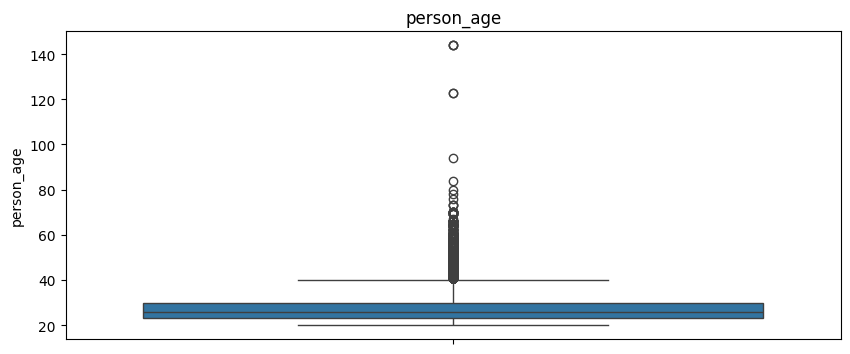

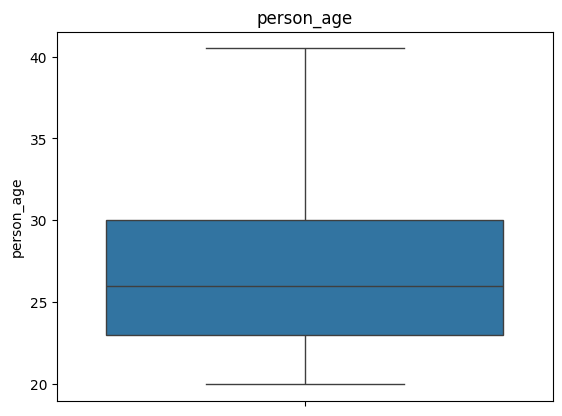

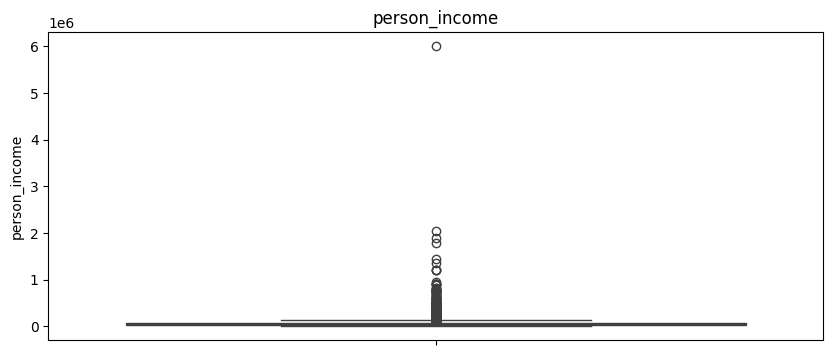

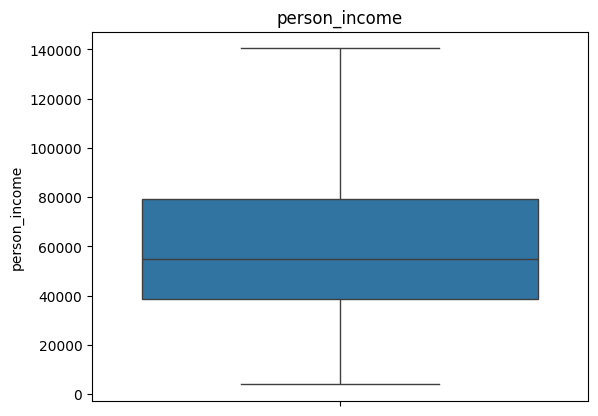

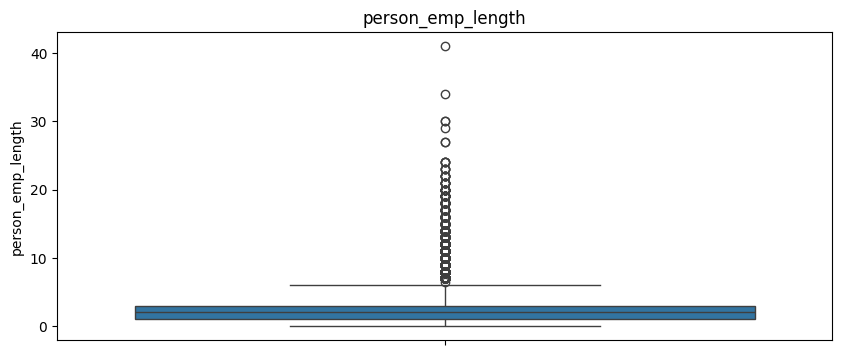

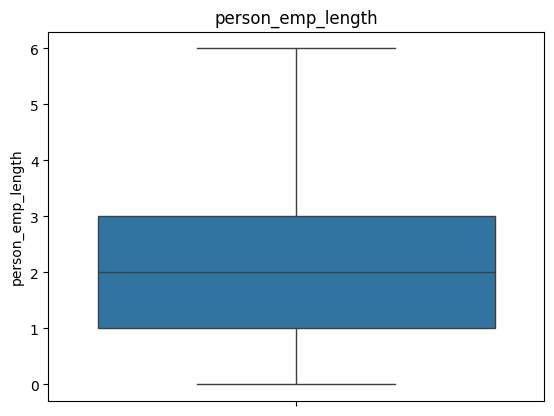

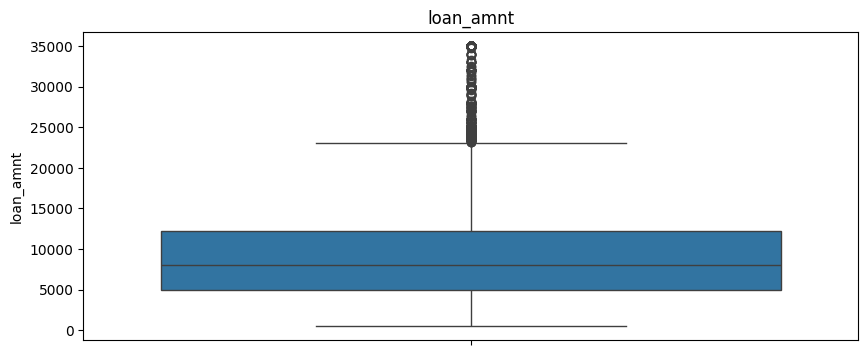

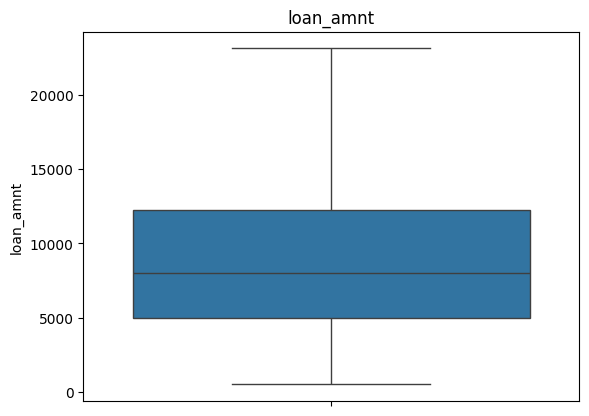

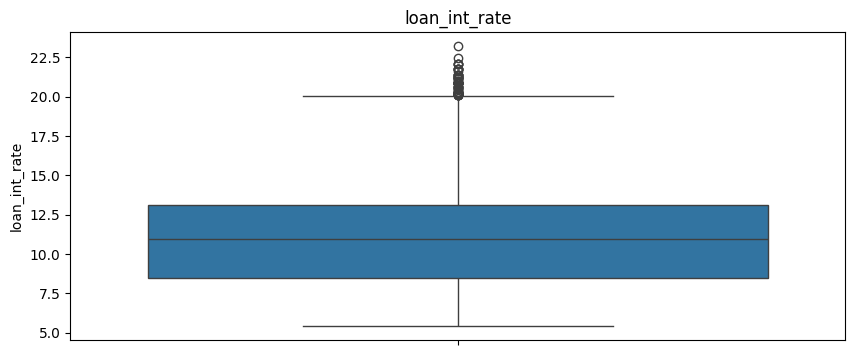

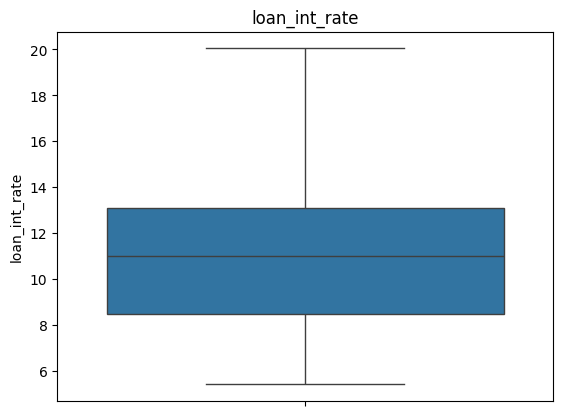

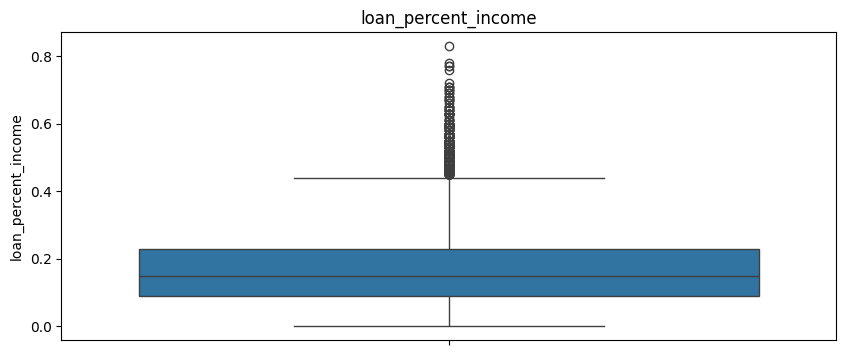

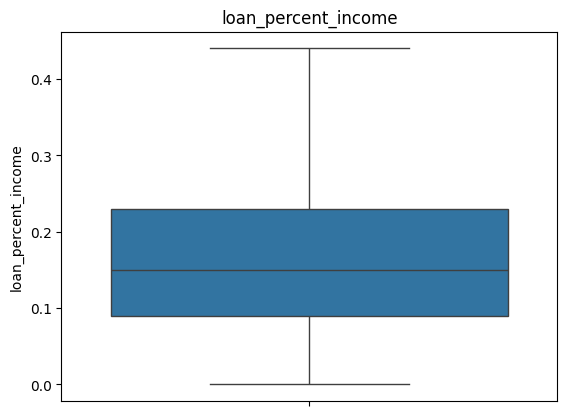

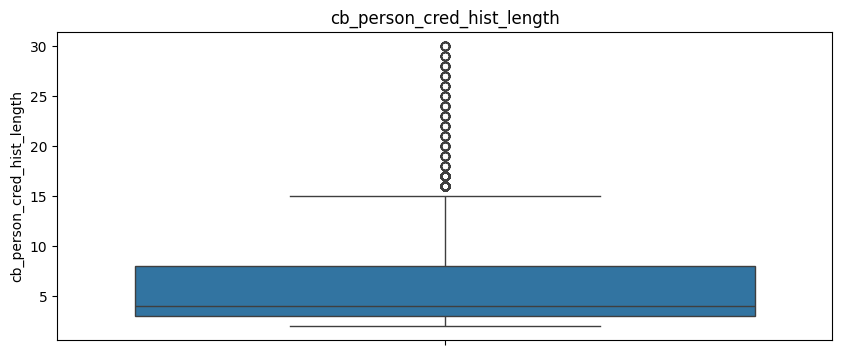

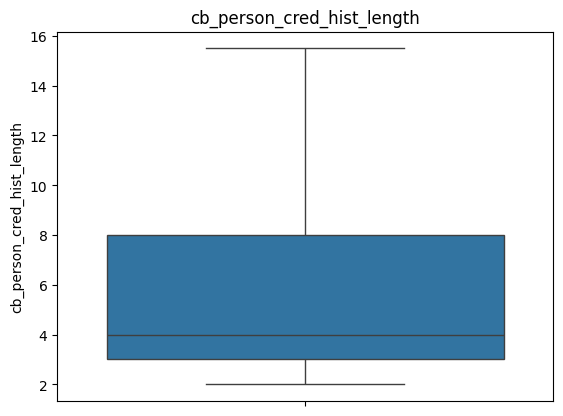

In [ ]:
for col in num_cols.drop("loan_status"):


    plt.figure(figsize=(10,4))

    sns.boxplot(df[col])

    plt.title(col)

    plt.show()
    Q1=df[col].quantile(0.25)
    Q2=df[col].quantile(0.5)
    Q3=df[col].quantile(0.75)
    iqr=Q3-Q1
    lowlim=Q1-1.5*iqr
    upplim=Q3+1.5*iqr
    df[col]=np.clip(df[col],a_min=lowlim,a_max=upplim)
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()


# *Exploratory Data Analysis*

loan_status
Non_Default    78.12982
Default        21.87018
Name: count, dtype: float64


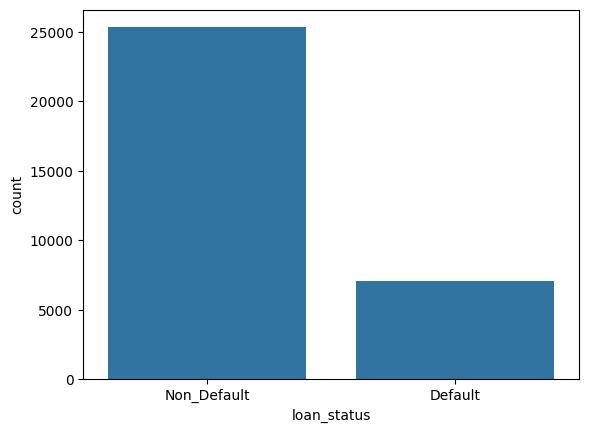

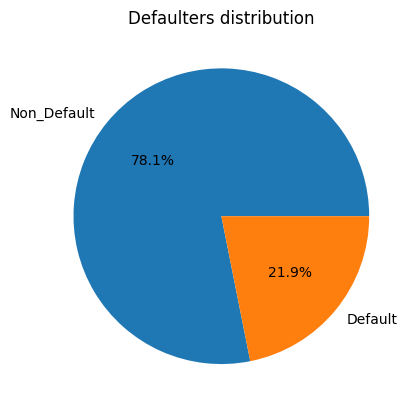

In [ ]:
#Default Distribution
print((df.loan_status.value_counts()/df.loan_status.shape*100).rename({0:"Non_Default",1:"Default"}))
sns.countplot(data=df,x="loan_status")
plt.xticks([0,1],["Non_Default","Default"])
plt.show()
plt.pie(df.loan_status.value_counts(),labels=["Non_Default","Default"],autopct="%1.1f%%")
plt.title("Defaulters distribution")
plt.show()

Income-Wise Default Analysis

In [ ]:
num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

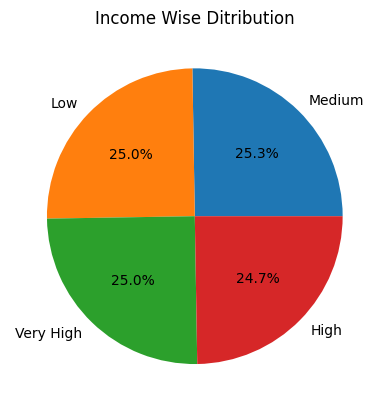

person_income
Low          39.745805
Medium       21.409380
High         17.148915
Very High     9.131293
Name: Default Rate, dtype: float64


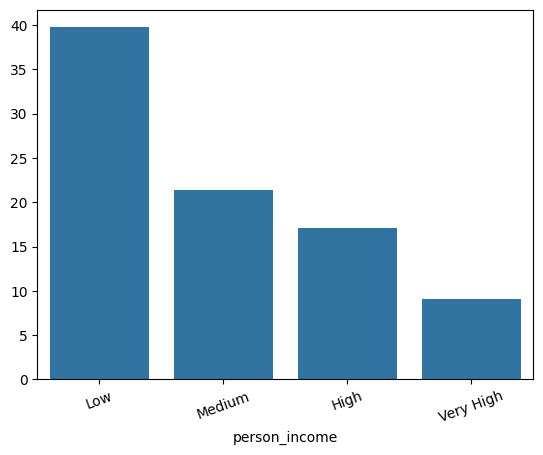

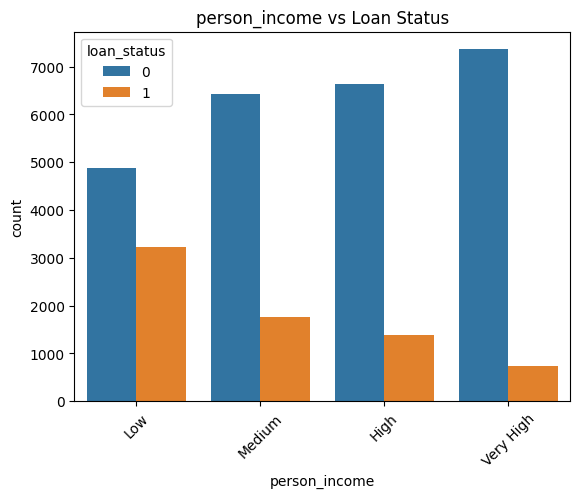

In [ ]:
#person_income vs Default
df1=df.loc[:,["person_income","loan_status"]]
df1["person_income"]=pd.cut(df1["person_income"],bins=[0, 38500, 55000, 79200, float("inf")],labels=["Low", "Medium", "High", "Very High"],include_lowest=True)
plt.pie(df1.person_income.value_counts(),labels=df1.person_income.value_counts().index,autopct="%1.1f%%")
plt.title("Income Wise Ditribution")
plt.show()
Default_Rate=(df1.groupby(by="person_income",observed=False)["loan_status"].mean()*100).rename("Default Rate")
print(Default_Rate)
sns.barplot(x=Default_Rate.index, y=Default_Rate.values)
plt.xticks(rotation=20)
plt.show()
sns.countplot(x="person_income", hue="loan_status", data=df1)

plt.xticks(rotation=45)

plt.title("person_income vs Loan Status")

plt.show()



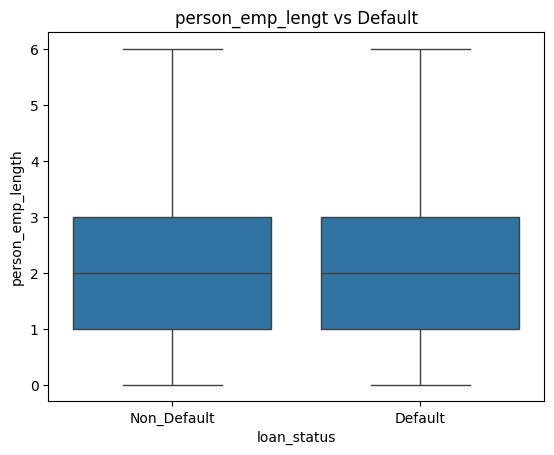

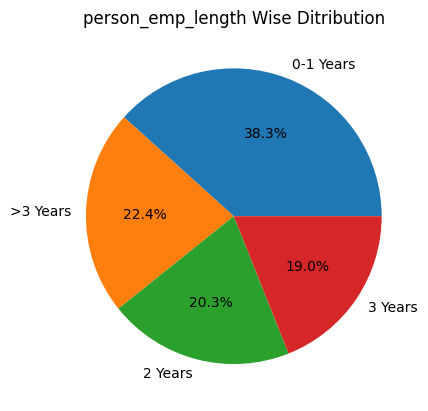

person_emp_length
0-1 Years    25.068427
2 Years      22.217153
3 Years      19.091797
>3 Years     18.440594
Name: Default Rate, dtype: float64


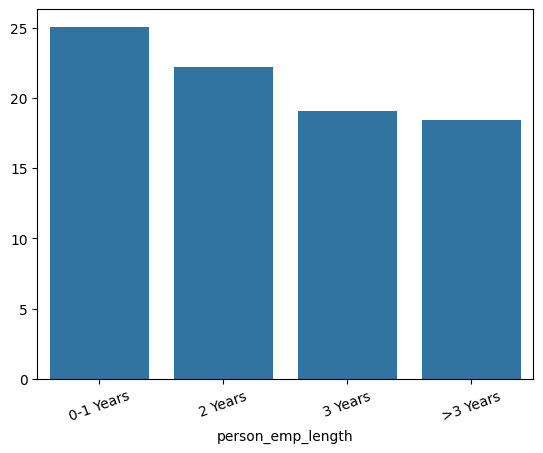

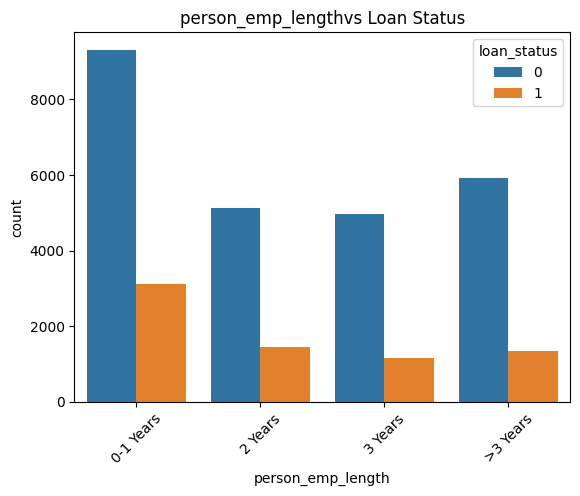

In [ ]:
#person_emp_length vs Default
sns.boxplot(x='loan_status', y='person_emp_length', data=df)
plt.title("person_emp_lengt vs Default")
plt.xticks([0,1],["Non_Default","Default"])
plt.show()

df2=df.loc[:,["person_emp_length","loan_status"]]
df2["person_emp_length"]=pd.cut(df2["person_emp_length"],bins=[-1, 1, 2, 3, float("inf")],labels=["0-1 Years", "2 Years", "3 Years", ">3 Years"],include_lowest=True)
plt.pie(df2.person_emp_length.value_counts(),labels=df2.person_emp_length.value_counts().index,autopct="%1.1f%%")
plt.title("person_emp_length Wise Ditribution")
plt.show()
Default_Rate=(df2.groupby(by="person_emp_length",observed=False)["loan_status"].mean()*100).rename("Default Rate")
print(Default_Rate)
sns.barplot(x=Default_Rate.index, y=Default_Rate.values)
plt.xticks(rotation=20)
plt.show()
sns.countplot(x="person_emp_length", hue="loan_status", data=df2)

plt.xticks(rotation=45)

plt.title("person_emp_lengthvs Loan Status")

plt.show()



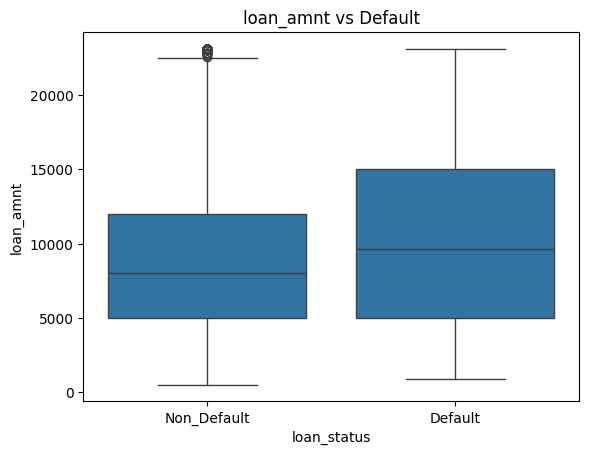

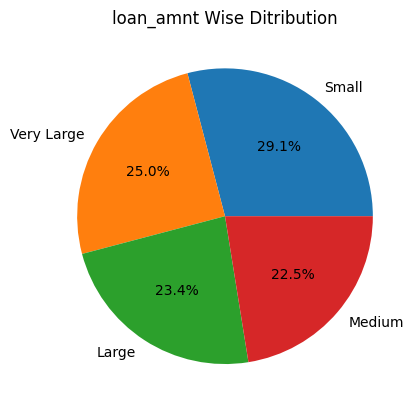

loan_amnt
Small         20.466596
Medium        16.701003
Large         20.028970
Very Large    29.868048
Name: Default Rate, dtype: float64


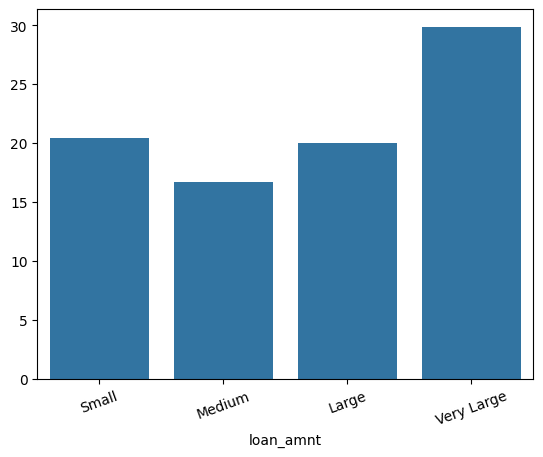

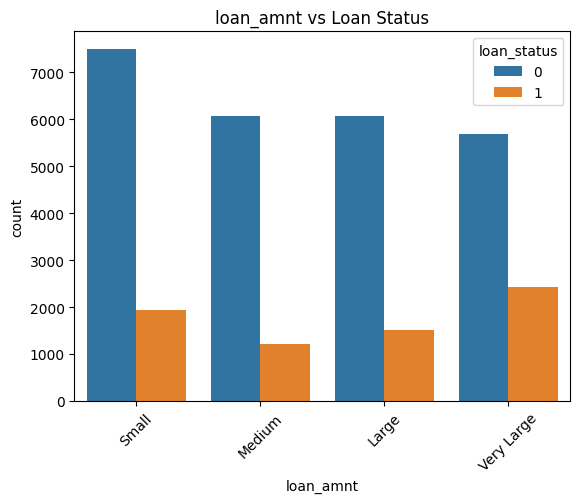

In [ ]:
#loan_amnt vs Default
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title("loan_amnt vs Default")
plt.xticks([0,1],["Non_Default","Default"])
plt.show()

df2=df.loc[:,["loan_amnt","loan_status"]]
df2["loan_amnt"]=pd.cut(df2["loan_amnt"],bins=[0, 5000, 8000, 12200, float("inf")],labels=["Small", "Medium", "Large", "Very Large"],include_lowest=True)
plt.pie(df2.loan_amnt.value_counts(),labels=df2.loan_amnt.value_counts().index,autopct="%1.1f%%")
plt.title("loan_amnt Wise Ditribution")
plt.show()
Default_Rate=(df2.groupby(by="loan_amnt",observed=False)["loan_status"].mean()*100).rename("Default Rate")
print(Default_Rate)
sns.barplot(x=Default_Rate.index, y=Default_Rate.values)
plt.xticks(rotation=20)
plt.show()
sns.countplot(x="loan_amnt", hue="loan_status", data=df2)

plt.xticks(rotation=45)

plt.title("loan_amnt vs Loan Status")

plt.show()



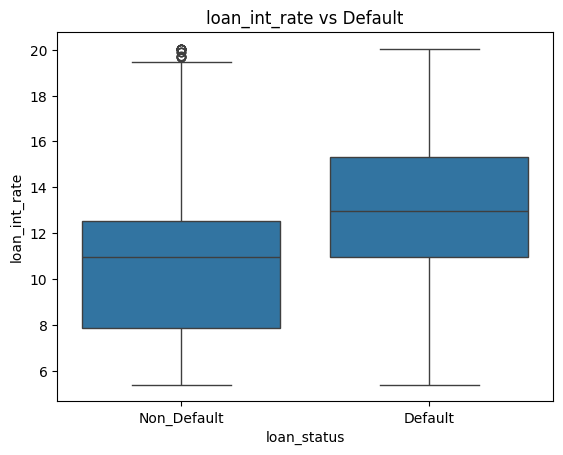

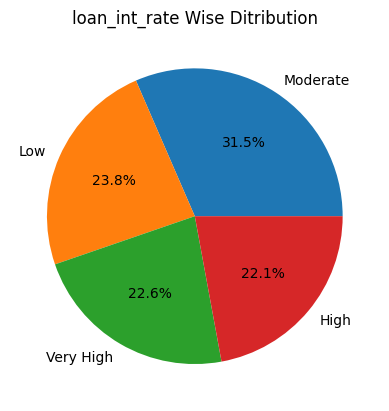

loan_int_rate
Low           9.359990
Moderate     16.816758
High         19.148639
Very High    44.720327
Name: Default Rate, dtype: float64


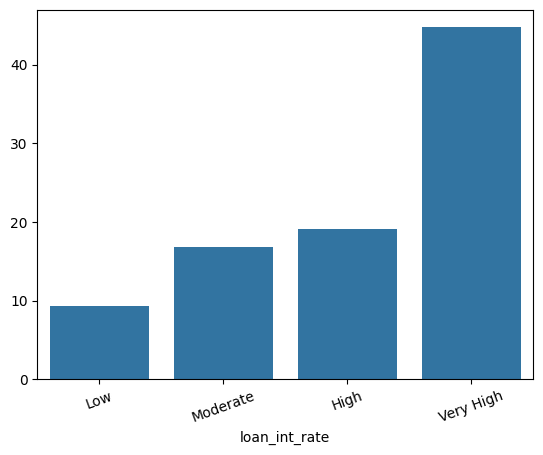

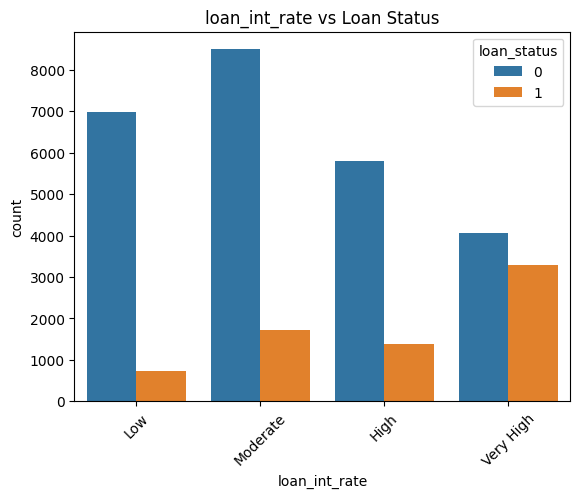

In [ ]:
#loan_int_rate vs Default
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title("loan_int_rate vs Default")
plt.xticks([0,1],["Non_Default","Default"])
plt.show()

df3=df.loc[:,["loan_int_rate","loan_status"]]
df3["loan_int_rate"]=pd.cut(df3["loan_int_rate"],
    bins=[0, 7.9, 10.99, 13.47, float("inf")],labels=["Low", "Moderate", "High", "Very High"],include_lowest=True)
plt.pie(df3.loan_int_rate.value_counts(),labels=df3.loan_int_rate.value_counts().index,autopct="%1.1f%%")
plt.title("loan_int_rate Wise Ditribution")
plt.show()
Default_Rate=(df3.groupby(by="loan_int_rate",observed=False)["loan_status"].mean()*100).rename("Default Rate")
print(Default_Rate)
sns.barplot(x=Default_Rate.index, y=Default_Rate.values)
plt.xticks(rotation=20)
plt.show()
sns.countplot(x="loan_int_rate", hue="loan_status", data=df3)

plt.xticks(rotation=45)

plt.title("loan_int_rate vs Loan Status")

plt.show()



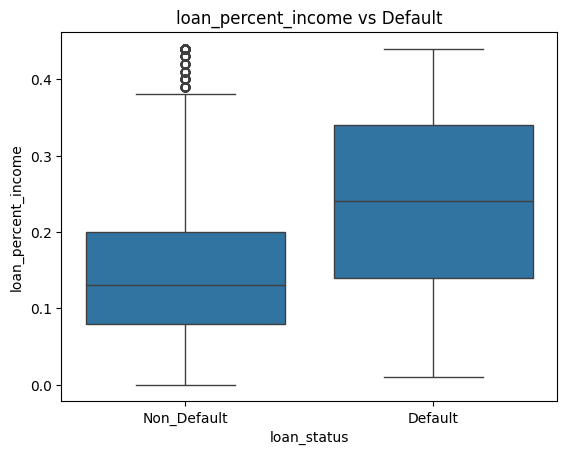

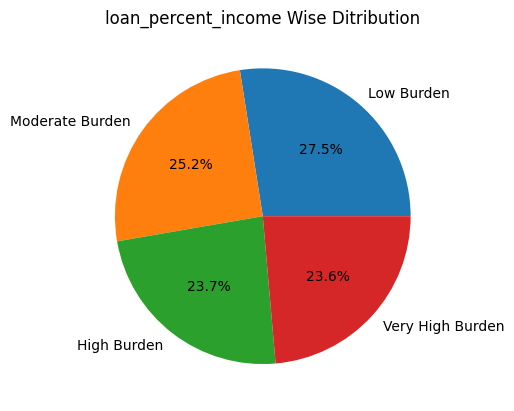

loan_percent_income
Low Burden          11.587694
Moderate Burden     12.819259
High Burden         18.657106
Very High Burden    46.727629
Name: Default Rate, dtype: float64


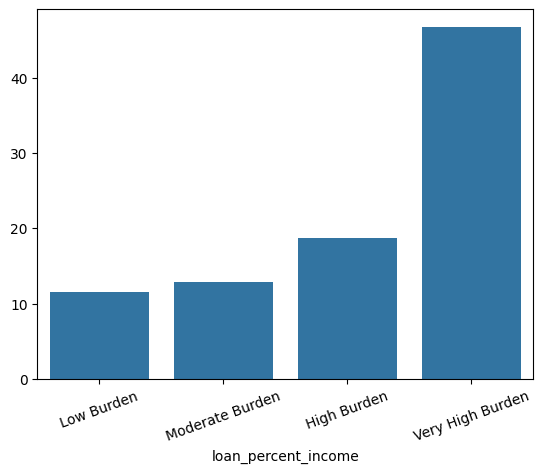

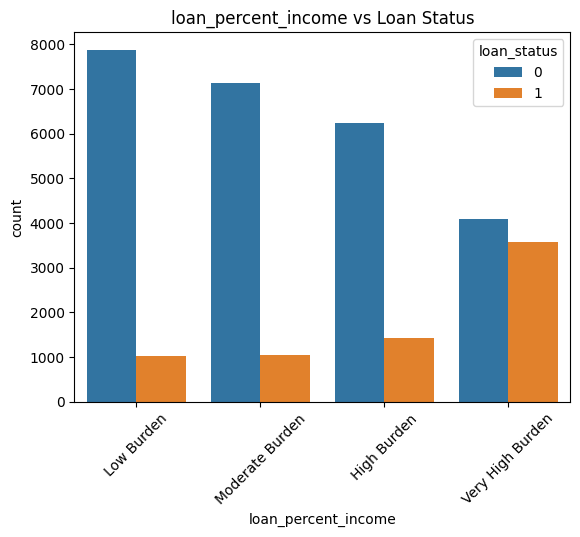

In [ ]:
#loan_percent_income vs Default
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title("loan_percent_income vs Default")
plt.xticks([0,1],["Non_Default","Default"])
plt.show()

df4=df.loc[:,["loan_percent_income","loan_status"]]
df4["loan_percent_income"]=pd.cut(df4["loan_percent_income"],
    bins=[0, 0.09, 0.15, 0.23, float("inf")], labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],include_lowest=True)
plt.pie(df4.loan_percent_income.value_counts(),labels=df4.loan_percent_income.value_counts().index,autopct="%1.1f%%")
plt.title("loan_percent_income Wise Ditribution")
plt.show()
Default_Rate=(df4.groupby(by="loan_percent_income",observed=False)["loan_status"].mean()*100).rename("Default Rate")
print(Default_Rate)
sns.barplot(x=Default_Rate.index, y=Default_Rate.values)
plt.xticks(rotation=20)
plt.show()
sns.countplot(x="loan_percent_income", hue="loan_status", data=df4)

plt.xticks(rotation=45)

plt.title("loan_percent_income vs Loan Status")

plt.show()



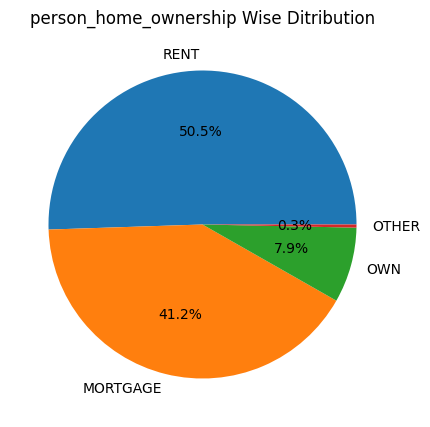

person_home_ownership
MORTGAGE    12.619689
OTHER       31.132075
OWN          7.491221
RENT        31.611406
Name: Default Rate, dtype: float64


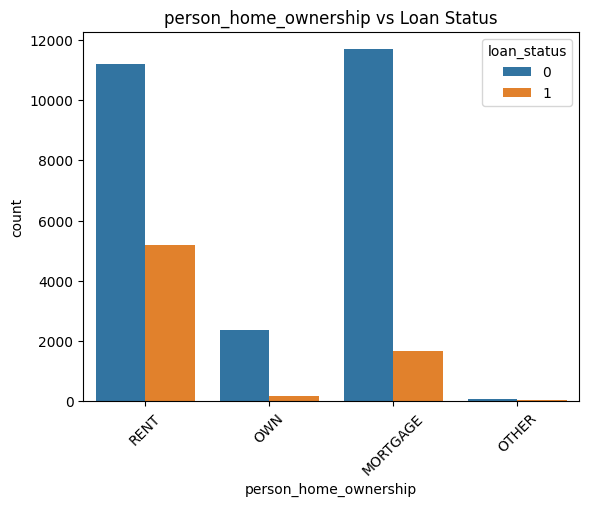

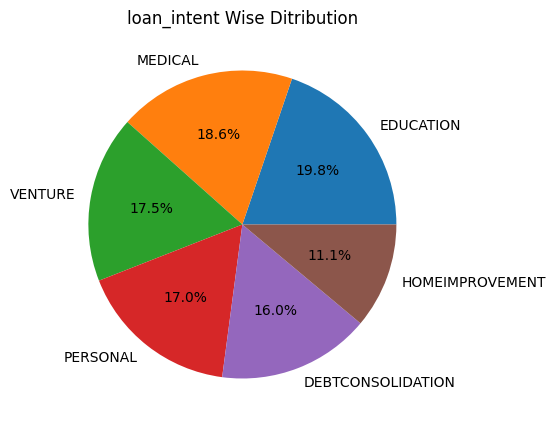

loan_intent
DEBTCONSOLIDATION    28.676045
EDUCATION            17.254290
HOMEIMPROVEMENT      26.154702
MEDICAL              26.762661
PERSONAL             19.898145
VENTURE              14.856539
Name: Default Rate, dtype: float64


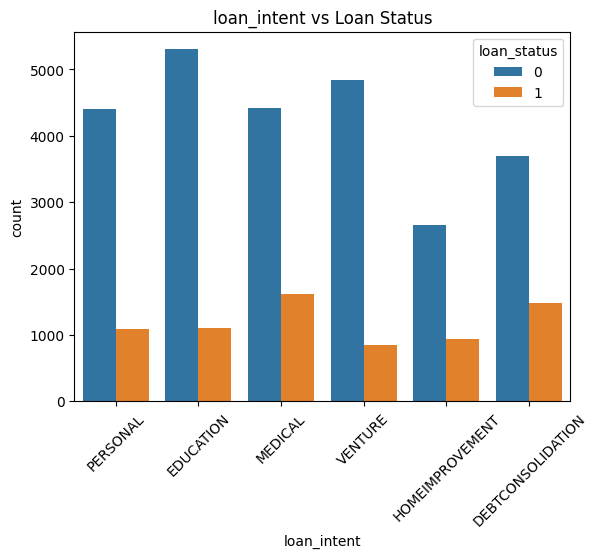

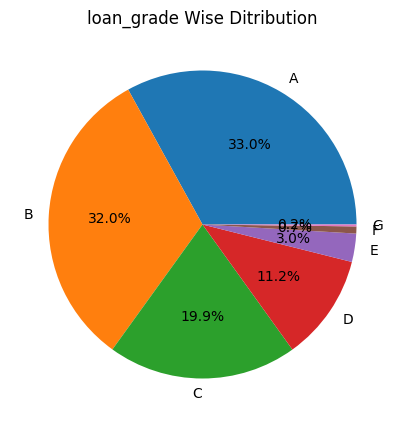

loan_grade
A     9.960755
B    16.320046
C    20.751786
D    59.060773
E    64.485981
F    70.539419
G    98.437500
Name: Default Rate, dtype: float64


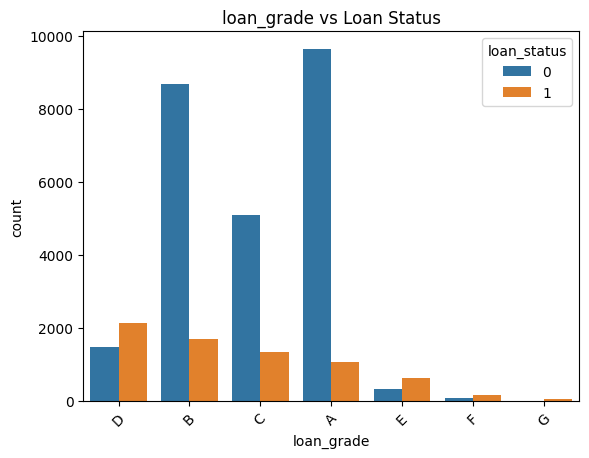

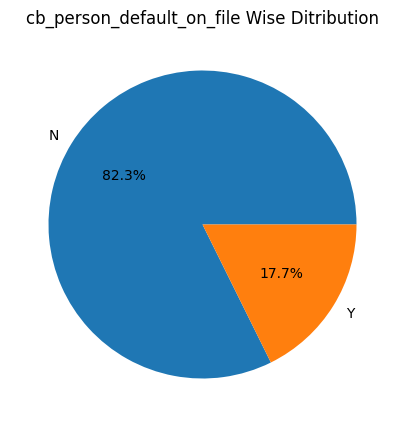

cb_person_default_on_file
N    18.434268
Y    37.870855
Name: Default Rate, dtype: float64


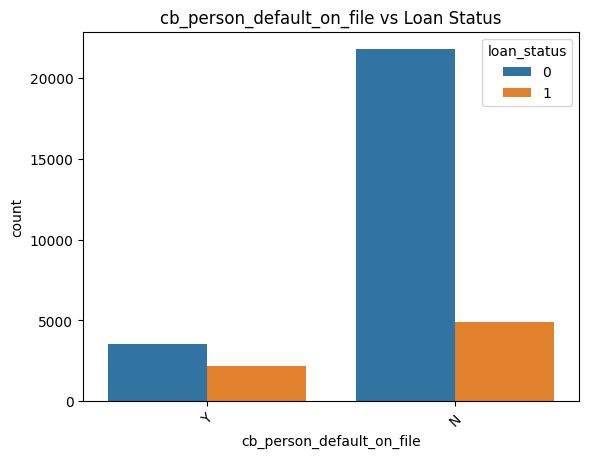

In [ ]:
for col in cat_cols:

    plt.figure(figsize=(7,5))
    plt.pie(df[col].value_counts(),labels=df[col].value_counts().index,autopct="%1.1f%%")
    plt.title(f"{col} Wise Ditribution")
    plt.show()
    Default_Rate=(df.groupby(by=col,observed=False)["loan_status"].mean()*100).rename("Default Rate")
    print(Default_Rate)
    sns.countplot(x=col, hue="loan_status", data=df)

    plt.xticks(rotation=45)

    plt.title(f"{col} vs Loan Status")

    plt.show()


# *Finding Correlation*

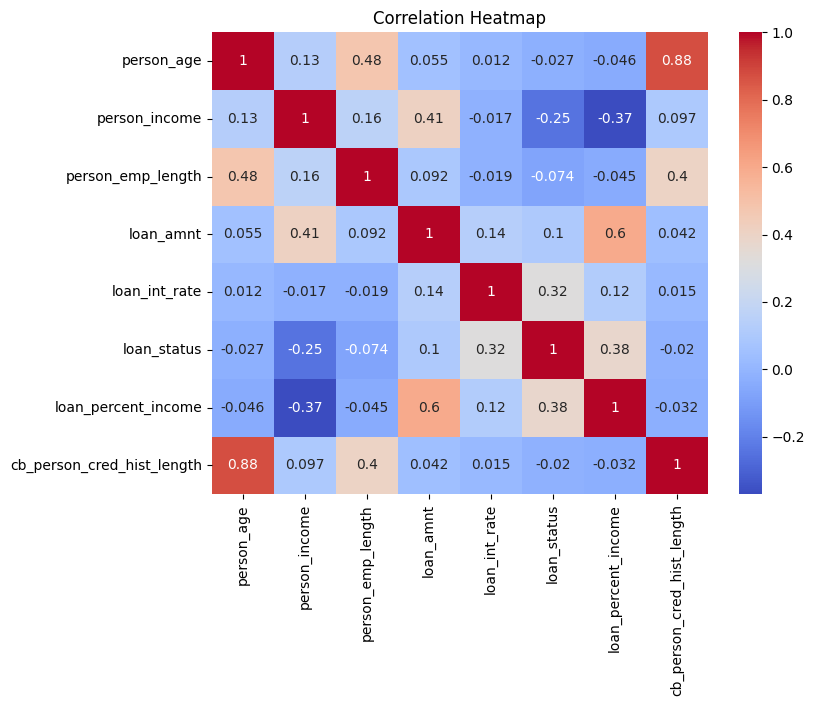

In [ ]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# FEATURE & TARGET SPLIT

In [ ]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [ ]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns

num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# DATA PREPROCESSING PIPELINE

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",drop="first"), cat_cols)
    ]
)

# Model Development

In [ ]:
lr = Pipeline(steps=[
    ("preprocessor", preprocessor),

    ("smoteenn", SMOTEENN(random_state=42)),

    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall   :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_lr))
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Accuracy : 0.8061082832022212
Precision: 0.5386833253243632
Recall   : 0.7905500705218618
F1 Score : 0.6407545012860817
ROC AUC  : 0.8718610113656456
[[4105  960]
 [ 297 1121]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5065
           1       0.54      0.79      0.64      1418

    accuracy                           0.81      6483
   macro avg       0.74      0.80      0.75      6483
weighted avg       0.85      0.81      0.82      6483



In [ ]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy : 0.9196359710010797
Precision: 0.8728179551122195
Recall   : 0.7404795486600846
F1 Score : 0.8012209080503625
ROC AUC  : 0.9295717032595997
[[4912  153]
 [ 368 1050]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5065
           1       0.87      0.74      0.80      1418

    accuracy                           0.92      6483
   macro avg       0.90      0.86      0.88      6483
weighted avg       0.92      0.92      0.92      6483



In [ ]:
xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.5,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test,y_pred_xgb))
print("Precision:", precision_score(y_test,y_pred_xgb))
print("Recall   :", recall_score(y_test,y_pred_xgb))
print("F1 Score :", f1_score(y_test,y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_xgb))
print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

Accuracy : 0.9281196976708314
Precision: 0.8973288814691152
Recall   : 0.7581100141043724
F1 Score : 0.8218654434250765
ROC AUC  : 0.9427945871512369
[[4942  123]
 [ 343 1075]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.95      5065
           1       0.90      0.76      0.82      1418

    accuracy                           0.93      6483
   macro avg       0.92      0.87      0.89      6483
weighted avg       0.93      0.93      0.93      6483



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb)
    ]
})

results.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.928120,0.897329,0.75811,0.821865,0.942795
1,Random Forest,0.919636,0.872818,0.74048,0.801221,0.929572
0,Logistic Regression,0.806108,0.538683,0.79055,0.640755,0.871861


# *Business Cost Analysis & Threshold Optimization*

,Threshold,TN,FP,FN,TP,Precision,Recall,Business_Cost
0,0.25,4727,338,271,1147,0.772391,0.808886,3319
1,0.26,4746,319,272,1146,0.782253,0.808181,3311
2,0.27,4762,303,274,1144,0.790601,0.806770,3317
3,0.28,4771,294,279,1139,0.794836,0.803244,3363
4,0.29,4782,283,284,1134,0.800282,0.799718,3407
5,0.30,4798,267,288,1130,0.808876,0.796897,3435
6,0.31,4808,257,292,1126,0.814172,0.794076,3469
7,0.32,4816,249,296,1122,0.818381,0.791255,3505
8,0.33,4831,234,297,1121,0.827306,0.790550,3501
9,0.34,4839,226,300,1118,0.831845,0.788434,3526


Best Threshold : 0.26
Minimum Business Cost : 3311.0


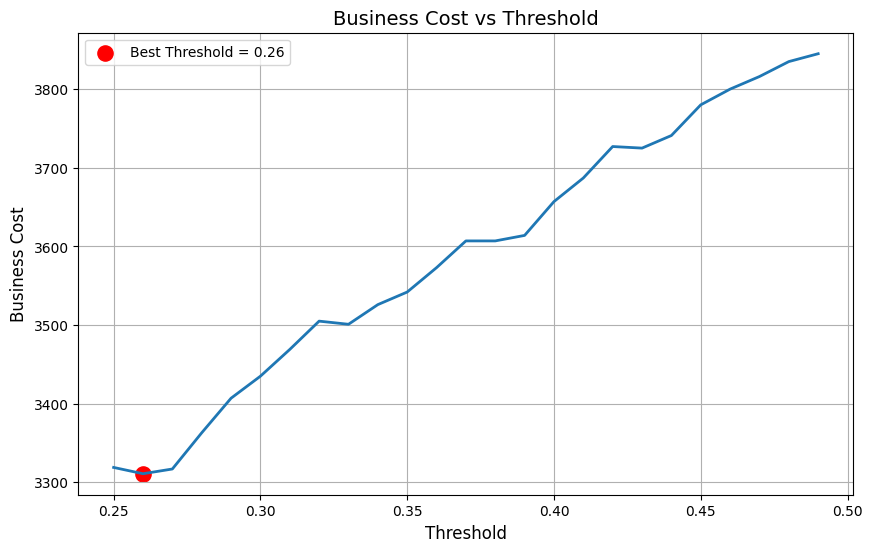


Classification Report

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      5065
           1       0.78      0.81      0.80      1418

    accuracy                           0.91      6483
   macro avg       0.86      0.87      0.87      6483
weighted avg       0.91      0.91      0.91      6483



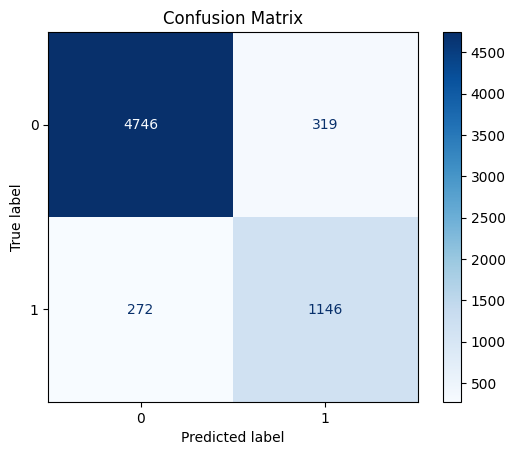

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay



# Define business costs
cost_fp = 1      # Rejecting a good customer
cost_fn = 11   # Approving a defaulter

# Threshold range
thresholds = np.arange(0.25, 0.5, 0.01)

results = []

for threshold in thresholds:

    y_pred = (y_prob_xgb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    business_cost = (fp * cost_fp) + (fn * cost_fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results.append([
        threshold,
        tn,
        fp,
        fn,
        tp,
        precision,
        recall,
        business_cost
    ])

# Create DataFrame
cost_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Precision",
        "Recall",
        "Business_Cost"
    ]
)

# Display results
display(cost_df)

# ============================================
# Best Threshold
# ============================================

best = cost_df.loc[cost_df["Business_Cost"].idxmin()]

best_threshold = best["Threshold"]

print("="*60)
print(f"Best Threshold : {best_threshold:.2f}")
print(f"Minimum Business Cost : {best['Business_Cost']}")
print("="*60)

# ============================================
# Business Cost Plot
# ============================================

plt.figure(figsize=(10,6))

plt.plot(
    cost_df["Threshold"],
    cost_df["Business_Cost"],
    linewidth=2
)

plt.scatter(
    best_threshold,
    best["Business_Cost"],
    color="red",
    s=120,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold", fontsize=12)

plt.ylabel("Business Cost", fontsize=12)

plt.title("Business Cost vs Threshold", fontsize=14)

plt.grid(True)

plt.legend()

plt.show()

# ============================================
# Final Prediction
# ============================================

y_pred_final = (y_prob_xgb >= best_threshold).astype(int)

# ============================================
# Classification Report
# ============================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_final))

# ============================================
# Confusion Matrix
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(xgb, "/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/credit_risk_finalmodel.pkl")

['/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/credit_risk_finalmodel.pkl']

In [ ]:
!pip install -q langchain-community langchain-text-splitters langchain-huggingface faiss-cpu pypdf sentence-transformers langchain_groq

import os
import joblib

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate

from huggingface_hub import InferenceClient
from langchain_groq import ChatGroq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
model = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/credit_risk_finalmodel.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
GROQ_API_KEY="gsk_"

In [ ]:
llm = ChatGroq(

    groq_api_key=GROQ_API_KEY,

    model_name="llama-3.3-70b-versatile",

    temperature=0.2

)

In [ ]:


pdf_path = "/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/documents/Feature_Reference_Guide.pdf"

loader = PyPDFLoader(pdf_path)

documents = loader.load()

print(len(documents))

10


In [ ]:
splitter=RecursiveCharacterTextSplitter(

    chunk_size=500,

    chunk_overlap=50

)

docs=splitter.split_documents(documents)

print(len(docs))

39


In [ ]:
embedding=HuggingFaceEmbeddings(

    model_name="sentence-transformers/all-MiniLM-L6-v2"

)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
vector_db=FAISS.from_documents(

    docs,

    embedding

)


In [ ]:
vector_db.save_local("/content/drive/MyDrive/Colab Notebooks/Credit Risk dataset/vector_db")

In [ ]:
retriever = vector_db.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 10,
        "fetch_k": 15
    }
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([

    (
        "system",
        """
You are an experienced Credit Risk Underwriter.

Rules:
- Use ONLY the Credit Risk Knowledge Guide provided in the context.
- The knowledge guide is developed from historical data analysis.
- Do NOT invent facts or explanations.
- Do NOT use external knowledge.
- If the context does not contain sufficient information, clearly mention it.
- Keep the report professional, concise and easy to understand.
"""
    ),

    (
        "human",
        """
Credit Risk Knowledge Guide

{context}

Applicant Information

{question}

Using ONLY the Credit Risk Knowledge Guide, generate a professional underwriting report.

## Underwriting Report

### 1. Risk Summary
Summarize the applicant's overall credit risk.

### 2. Feature-wise Explanation

Explain how the relevant applicant characteristics influence the applicant's credit risk based on the historical data analysis.

Discuss only the relevant features such as:

- Employment Length
- Home Ownership
- Loan Intent
- Loan Grade
- Loan Amount
- Interest Rate
- Loan Percent Income
- Previous Default History
- Credit History Length

### 3. Decision Justification

The machine learning model has already produced the following result.

Explain why the following prediction is appropriate:

- Probability of Default
- Risk Score
- Lending Decision

Use ONLY the Credit Risk Knowledge Guide.


Do NOT make a new lending decision.
Do NOT contradict the machine learning decision.
"""
    )

])


In [ ]:
from textwrap import dedent

def d(applicant):

    income_cat = pd.cut(
        applicant["person_income"],
        bins=[0, 38500, 55000, 79200, float("inf")],
        labels=["Low", "Medium", "High", "Very High"]
    ).iloc[0]

    loan_cat = pd.cut(
        applicant["loan_amnt"],
        bins=[0, 5000, 8000, 12200, float("inf")],
        labels=["Small", "Medium", "Large", "Very Large"]
    ).iloc[0]

    rate_cat = pd.cut(
        applicant["loan_int_rate"],
        bins=[0, 7.9, 10.99, 13.47, float("inf")],
        labels=["Low", "Moderate", "High", "Very High"]
    ).iloc[0]

    burden_cat = pd.cut(
        applicant["loan_percent_income"],
        bins=[0, 0.09, 0.15, 0.23, float("inf")],
        labels=[
            "Low Burden",
            "Moderate Burden",
            "High Burden",
            "Very High Burden"
        ]
    ).iloc[0]

    emp_cat = pd.cut(
        applicant["person_emp_length"],
        bins=[-1, 1, 2, 3, float("inf")],
        labels=["0-1 Years", "2 Years", "3 Years", ">3 Years"]
    ).iloc[0]

    question = dedent(f"""
    Applicant Information

    Age: {applicant['person_age'].iloc[0]}

    Income:  ${applicant['person_income'].iloc[0]:,.0f} ({income_cat})

    Home Ownership: {applicant['person_home_ownership'].iloc[0]}

    Employment Length: {applicant['person_emp_length'].iloc[0]} Years ({emp_cat})

    Loan Intent: {applicant['loan_intent'].iloc[0]}

    Loan Grade: {applicant['loan_grade'].iloc[0]}

    Loan Amount:  ${applicant['loan_amnt'].iloc[0]:,.0f} ({loan_cat})

    Interest Rate: {applicant['loan_int_rate'].iloc[0]:.2f}% ({rate_cat})

    Loan Percent Income: {applicant['loan_percent_income'].iloc[0]:.2f} ({burden_cat})

    Previous Default History: {applicant['cb_person_default_on_file'].iloc[0]}

    Credit History Length: {applicant['cb_person_cred_hist_length'].iloc[0]} Years
    """)

    return question

In [ ]:
chain = prompt | llm

In [ ]:
def predict_and_explain(applicant):

    # ---------------- Prediction ---------------- #

    probability = float(model.predict_proba(applicant)[0][1])

    risk_score = round(probability * 100, 2)

    if risk_score < 20:
        decision = "APPROVE"

    elif risk_score < 50:
        decision = "MANUAL REVIEW"

    else:
        decision = "REJECT"

    # ---------------- Applicant Information ---------------- #

    applicant_info = d(applicant)

    # ---------------- Retrieve Context ---------------- #

    docs = retriever.invoke(applicant_info)

    context = "\n\n".join(
        doc.page_content for doc in docs
    )

    # ---------------- Question ---------------- #

    question = f"""
{applicant_info}

Machine Learning Prediction

Probability of Default : {probability:.4f}

Risk Score : {risk_score:.2f}

Lending Decision : {decision}
"""

    # ---------------- AI Report ---------------- #

    report = chain.invoke({

        "context": context,

        "question": question

    }).content

    # ---------------- Return ---------------- #

    return {

        "Probability": round(probability, 4),

        "Risk Score": risk_score,

        "Decision": decision,

        "Retrieved Context": context,

        "AI Report": report

    }

In [ ]:
sample = pd.DataFrame({

    "person_age":[30],
    "person_income":[50000],
    "person_home_ownership":["RENT"],
    "person_emp_length":[5],
    "loan_intent":["PERSONAL"],
    "loan_grade":["A"],
    "loan_amnt":[15000],
    "loan_int_rate":[12.5],
    "loan_percent_income":[15000/50000],
    "cb_person_default_on_file":["N"],
    "cb_person_cred_hist_length":[4]

})


In [ ]:
result = predict_and_explain(sample)

In [ ]:
print("Risk Score :", result["Risk Score"])
print("Decision :", result["Decision"])


print("\nAI Underwriting Report\n")
print(result["AI Report"])

Risk Score : 1.12
Decision : APPROVE

AI Underwriting Report

## Underwriting Report

### 1. Risk Summary
The applicant's overall credit risk is relatively low, with a predicted probability of default of 0.0112, which is significantly lower than the observed default rates for most categories in the Credit Risk Knowledge Guide.

### 2. Feature-wise Explanation
The applicant's characteristics have both positive and negative influences on their credit risk:
- **Employment Length**: The applicant has been employed for 5 years, which is greater than 3 years. However, the guide does not provide specific default rates for employment length, so we cannot directly assess its impact.
- **Home Ownership**: The applicant rents their home, with an observed default rate of 31.61%. This is one of the highest default rates among the home ownership categories, indicating a higher credit risk.
- **Loan Intent**: The applicant's loan intent is for personal use, with an observed default rate of 19.90%. Th